# Comparação semanal de preços de combustível

Médias semanais ANP e Petrobras no canal da distribuidora, para gasolina e diesel.


In [ ]:
import sys
from pathlib import Path

from IPython.display import display

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('seaborn-v0_8')

cwd = Path.cwd().resolve()
if (cwd / 'src').is_dir() and (cwd / 'data').is_dir():
    project_root = cwd
elif (cwd.parent / 'src').is_dir() and (cwd.parent / 'data').is_dir():
    project_root = cwd.parent
else:
    raise FileNotFoundError(
        'Could not locate proj_IV root (expected src/ and data/). '
        'Open notebooks from proj_IV/ or proj_IV/notebooks/.'
    )

sys.path.insert(0, str(project_root / 'src'))

from db_access import read_engine, resolve_database_url

ENGINE = read_engine(project_root)
DATABASE_URL = resolve_database_url(project_root)
DATABASE_URL

In [2]:
queries = {
    'anp_gasoline': "SELECT week_start, week_end, avg_price_rs_l, source_record_count FROM anp_distributor_weekly_gasoline ORDER BY week_start",
    'anp_diesel': "SELECT week_start, week_end, avg_price_rs_l, source_record_count FROM anp_distributor_weekly_diesel ORDER BY week_start",
    'petrobras_gasoline': "SELECT week_start, week_end, avg_price_rs_l, source_record_count FROM petrobras_distributor_weekly_gasoline ORDER BY week_start",
    'petrobras_diesel': "SELECT week_start, week_end, avg_price_rs_l, source_record_count FROM petrobras_distributor_weekly_diesel ORDER BY week_start",
}

anp_gasoline = pd.read_sql_query(queries['anp_gasoline'], ENGINE)
anp_diesel = pd.read_sql_query(queries['anp_diesel'], ENGINE)
petrobras_gasoline = pd.read_sql_query(queries['petrobras_gasoline'], ENGINE)
petrobras_diesel = pd.read_sql_query(queries['petrobras_diesel'], ENGINE)
ppi_anchor = pd.to_datetime(
    pd.read_sql_query('SELECT MIN(report_date) AS d FROM ppi_daily', ENGINE).iloc[0, 0]
)

for df in [anp_gasoline, anp_diesel, petrobras_gasoline, petrobras_diesel]:
    df['week_start'] = pd.to_datetime(df['week_start'], errors='coerce')
    df['week_end'] = pd.to_datetime(df['week_end'], errors='coerce')
anp_gasoline = anp_gasoline[anp_gasoline['week_start'] >= ppi_anchor].copy()
anp_diesel = anp_diesel[anp_diesel['week_start'] >= ppi_anchor].copy()
petrobras_gasoline = petrobras_gasoline[petrobras_gasoline['week_start'] >= ppi_anchor].copy()
petrobras_diesel = petrobras_diesel[petrobras_diesel['week_start'] >= ppi_anchor].copy()
print(f'PPI anchor: {ppi_anchor.date()}')

for name, df in [
    ('anp_gasoline', anp_gasoline),
    ('anp_diesel', anp_diesel),
    ('petrobras_gasoline', petrobras_gasoline),
    ('petrobras_diesel', petrobras_diesel),
]:
    if df.empty:
        raise ValueError(f'{name} is empty')

summary = pd.DataFrame([
    {'table': 'anp_distributor_weekly_gasoline', 'rows': len(anp_gasoline), 'min_week': anp_gasoline['week_start'].min(), 'max_week': anp_gasoline['week_start'].max()},
    {'table': 'anp_distributor_weekly_diesel', 'rows': len(anp_diesel), 'min_week': anp_diesel['week_start'].min(), 'max_week': anp_diesel['week_start'].max()},
    {'table': 'petrobras_distributor_weekly_gasoline', 'rows': len(petrobras_gasoline), 'min_week': petrobras_gasoline['week_start'].min(), 'max_week': petrobras_gasoline['week_start'].max()},
    {'table': 'petrobras_distributor_weekly_diesel', 'rows': len(petrobras_diesel), 'min_week': petrobras_diesel['week_start'].min(), 'max_week': petrobras_diesel['week_start'].max()},
])
display(summary)


PPI anchor: 2022-01-05


,table,rows,min_week,max_week
0,anp_distributor_weekly_gasoline,231,2022-01-10,2026-06-08
1,anp_distributor_weekly_diesel,231,2022-01-10,2026-06-08
2,petrobras_distributor_weekly_gasoline,62,2022-01-10,2026-05-25
3,petrobras_distributor_weekly_diesel,70,2022-01-10,2026-06-01


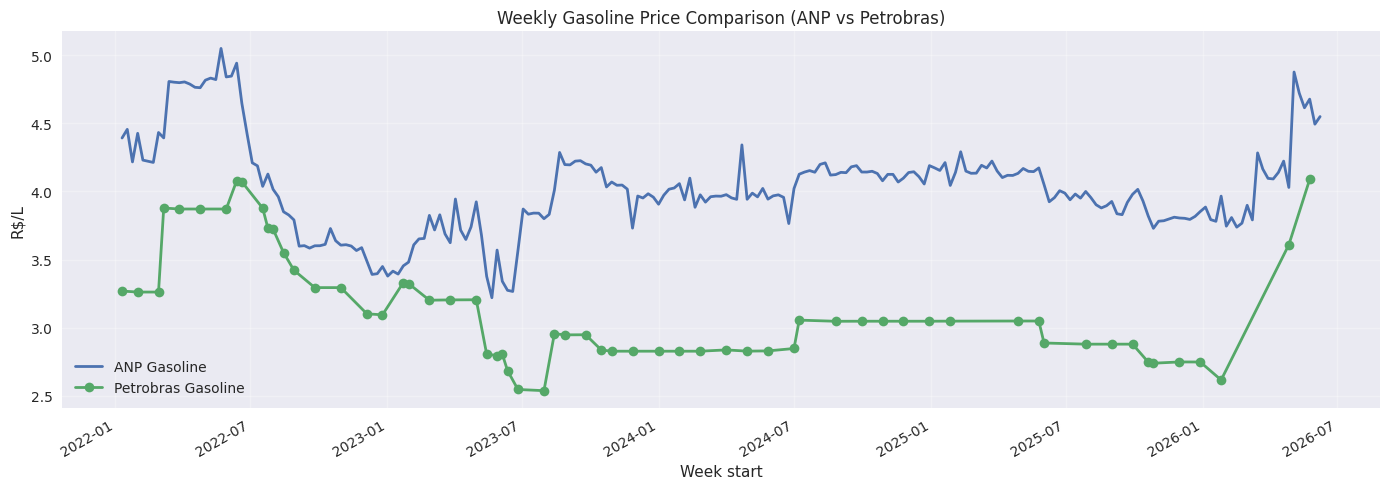

In [3]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(anp_gasoline['week_start'], anp_gasoline['avg_price_rs_l'], linewidth=2.0, label='ANP Gasoline')
ax.plot(petrobras_gasoline['week_start'], petrobras_gasoline['avg_price_rs_l'], linewidth=2.0, marker='o', label='Petrobras Gasoline')
ax.set_title('Weekly Gasoline Price Comparison (ANP vs Petrobras)')
ax.set_xlabel('Week start')
ax.set_ylabel('R$/L')
ax.grid(True, alpha=0.3)
ax.legend()
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()
